# HW3-3: Enhanced DQN for Random Mode with Training Tips

- **框架**：PyTorch Lightning
- **環境**：GridWorld `random` mode（所有物件位置全部隨機）
- **訓練技巧**：Gradient Clipping、Learning Rate Scheduling、ε Decay 優化

## Step 1：安裝 & 下載環境

In [1]:
# 安裝 PyTorch Lightning
!pip install lightning -q

# 下載 GridWorld 環境
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/Gridworld.py
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/GridBoard.py

print('安裝完成！')

安裝完成！


## Step 2：Import

In [2]:
import numpy as np
import torch
import torch.nn as nn
import lightning as L
import copy
import random
from collections import deque
from torch.utils.data import DataLoader, IterableDataset
from matplotlib import pylab as plt
from Gridworld import Gridworld
from IPython.display import clear_output

action_set = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}
print('Import 完成！')

Import 完成！


## Step 3：網路架構（Dueling DQN）
沿用 HW3-2 最好的架構

In [3]:
class DuelingQNetwork(nn.Module):
    """Dueling DQN 網路架構（沿用 HW3-2）"""
    def __init__(self, input_dim=64, hidden1=150, hidden2=100, n_actions=4):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU()
        )
        self.value_stream = nn.Linear(hidden2, 1)
        self.adv_stream   = nn.Linear(hidden2, n_actions)

    def forward(self, x):
        x = self.backbone(x)
        V = self.value_stream(x)
        A = self.adv_stream(x)
        return V + (A - A.mean(dim=1, keepdim=True))

print('網路架構定義完成！')

網路架構定義完成！


## Step 4：Experience Replay Buffer

In [4]:
class ReplayBuffer:
    """Experience Replay Buffer"""
    def __init__(self, capacity=1000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


class RLDataset(IterableDataset):
    def __init__(self, buffer, batch_size=200):
        self.buffer     = buffer
        self.batch_size = batch_size

    def __iter__(self):
        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        yield (
            torch.cat(list(states)),
            torch.tensor(list(actions), dtype=torch.long),
            torch.tensor(list(rewards), dtype=torch.float),
            torch.cat(list(next_states)),
            torch.tensor(list(dones),   dtype=torch.float)
        )

## Step 5：PyTorch Lightning Module

### 三個訓練技巧說明
1. **Gradient Clipping**：限制梯度最大值為 1.0，防止梯度爆炸
2. **Learning Rate Scheduling**：每 500 epoch 將 LR 乘以 0.9，讓後期收斂更穩
3. **ε Exponential Decay**：改用指數衰減（原本是線性），探索衰減更自然

In [6]:
class DQNLightning(L.LightningModule):
    def __init__(
        self,
        lr=1e-3,
        gamma=0.9,
        batch_size=200,
        sync_freq=500,
        eps_start=1.0,
        eps_end=0.1,
        eps_decay=0.9998,
        mode='random'
    ):
        super().__init__()
        self.save_hyperparameters()

        self.net    = DuelingQNetwork()
        self.target = DuelingQNetwork()
        self.target.load_state_dict(self.net.state_dict())
        self.target.eval()

        self.buffer     = ReplayBuffer(capacity=1000)
        self.loss_fn    = nn.MSELoss()
        self.epsilon    = eps_start
        self.losses     = []
        self.step_count = 0

    def _get_state(self, game):
        s = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        return torch.from_numpy(s).float()

    def _select_action(self, state):
        if random.random() < self.epsilon:
            return np.random.randint(0, 4)
        with torch.no_grad():
            return self.net(state).argmax().item()

    def _run_episode(self):
        """跑完一整場遊戲（模仿原本的 while 迴圈）"""
        game  = Gridworld(size=4, mode=self.hparams.mode)
        state = self._get_state(game)
        mov   = 0
        while True:
            mov += 1
            action_ = self._select_action(state)
            game.makeMove(action_set[action_])
            next_state = self._get_state(game)
            reward     = game.reward()
            done       = reward != -1
            self.buffer.push(state, action_, reward, next_state, done)
            state = next_state
            if done or mov >= 50:
                break

    def training_step(self, batch, batch_idx):
        # 跑完一整場遊戲，填充 buffer（對齊原本 while 迴圈）
        self._run_episode()
        self.step_count += 1

        # buffer 不夠就跳過這次訓練
        if len(self.buffer) < self.hparams.batch_size:
            return torch.tensor(0.0, requires_grad=True)

        # 解包 batch
        states      = batch[0].squeeze(0).float()
        actions     = batch[1].squeeze(0).long()
        rewards     = batch[2].squeeze(0).float()
        next_states = batch[3].squeeze(0).float()
        dones       = batch[4].squeeze(0).float()

        # 計算 Q 值（Double DQN）
        Q1 = self.net(states)
        with torch.no_grad():
            best_actions = self.net(next_states).argmax(dim=1)
            Q2 = self.target(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)

        Y = rewards + self.hparams.gamma * ((1 - dones) * Q2)
        X = Q1.gather(1, actions.unsqueeze(1)).squeeze(1)
        loss = self.loss_fn(X, Y.detach())

        # Target network 同步
        if self.step_count % self.hparams.sync_freq == 0:
            self.target.load_state_dict(self.net.state_dict())

        # ε 指數衰減
        self.epsilon = max(
            self.hparams.eps_end,
            self.epsilon * self.hparams.eps_decay
        )

        self.log('train_loss', loss, prog_bar=True)
        self.log('epsilon',    self.epsilon, prog_bar=True)
        self.losses.append(loss.item())
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.net.parameters(), lr=self.hparams.lr)
        # 訓練技巧②：Learning Rate Scheduling
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=500, gamma=0.9
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'interval': 'step'}
        }

    def train_dataloader(self):
        # 預填 buffer
        while len(self.buffer) < self.hparams.batch_size:
            self._run_episode()
        dataset = RLDataset(self.buffer, self.hparams.batch_size)
        return DataLoader(dataset, batch_size=self.hparams.batch_size)

print('Lightning Module 定義完成！')

Lightning Module 定義完成！


## Step 6：訓練

In [7]:
# 建立模型
dqn = DQNLightning(
    lr=1e-3,
    gamma=0.9,
    batch_size=200,
    sync_freq=500,
    eps_start=1.0,
    eps_end=0.1,
    eps_decay=0.9998,
    mode='random'
)

trainer = L.Trainer(
    max_epochs=5000,
    gradient_clip_val=1.0,
    enable_checkpointing=False,
    enable_model_summary=False,
    logger=False,
)

print('開始訓練...')
trainer.fit(dqn)
print('訓練完成！')

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

開始訓練...


INFO: `Trainer.fit` stopped: `max_epochs=5000` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5000` reached.


訓練完成！


## Step 7：評估結果

In [8]:
def test_model(model, mode='random', n_games=500):
    """測試模型勝率"""
    wins = 0
    model.eval()
    for _ in range(n_games):
        game = Gridworld(size=4, mode=mode)
        state_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state  = torch.from_numpy(state_).float()
        status = 1
        i = 0
        while status == 1:
            with torch.no_grad():
                action_ = model(state).argmax().item()
            game.makeMove(action_set[action_])
            state_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
            state  = torch.from_numpy(state_).float()
            reward = game.reward()
            if reward == 10:
                wins += 1
                status = 0
            elif reward == -10:
                status = 0
            i += 1
            if i > 15:
                status = 0
    win_rate = wins / n_games * 100
    print(f'Games: {n_games} | Wins: {wins} | Win Rate: {win_rate:.1f}%')
    return win_rate

print('=== HW3-3 評估結果 ===')
win_rate = test_model(dqn.net, mode='random', n_games=500)

=== HW3-3 評估結果 ===
Games: 500 | Wins: 430 | Win Rate: 86.0%


## Step 8：Loss 曲線

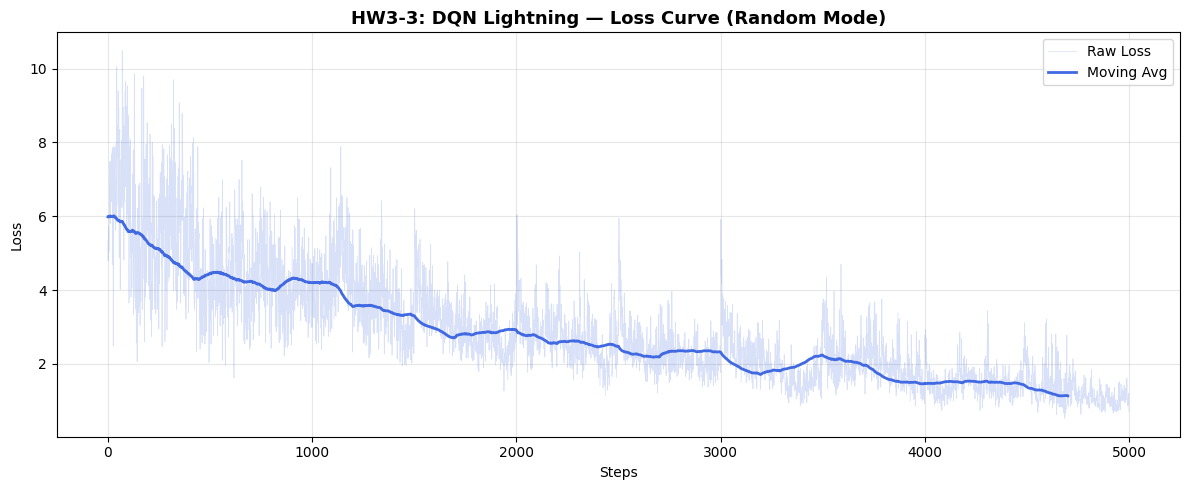


最終 ε 值：0.3678
總訓練步數：5000
最終勝率：86.0%


In [9]:
losses = np.array(dqn.losses)

def moving_avg(data, window=300):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(losses, alpha=0.2, color='royalblue', linewidth=0.5, label='Raw Loss')
if len(losses) > 300:
    plt.plot(moving_avg(losses), color='royalblue', linewidth=2, label='Moving Avg')
plt.title('HW3-3: DQN Lightning — Loss Curve (Random Mode)', fontsize=13, fontweight='bold')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hw33_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n最終 ε 值：{dqn.epsilon:.4f}')
print(f'總訓練步數：{dqn.step_count}')
print(f'最終勝率：{win_rate:.1f}%')